<a href="https://colab.research.google.com/github/sunilchhajwani/ChatGPT/blob/v2-dev/dengue_data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Predicting Cluster for a New Patient at Admission

This section demonstrates how to use the admission-only clustering model to predict which cluster a new patient belongs to, based on information available at the time of admission. This allows for immediate interpretation and planning.

In [25]:
import pandas as pd

# 1. Ask for necessary input on admission
print("Please enter the following details for the new patient at admission:")

age_input = int(input("Enter Age in Years: "))
result_input = input("Enter Result ('Positive' for dengue igm positive, 'Reactive' for dengue ns1 positive): ")
gender_input = input("Enter Gender ('M' or 'F'): ")

# Create a DataFrame for the new patient's admission data
new_patient_admission_data = pd.DataFrame({
    'Age in Years': [age_input],
    'Result': [result_input],
    'Gender': [gender_input]
})

print("\nNew Patient Admission Data:")
print(new_patient_admission_data)

Please enter the following details for the new patient at admission:
Enter Age in Years: 70
Enter Result ('Positive' for dengue igm positive, 'Reactive' for dengue ns1 positive): reactive
Enter Gender ('M' or 'F'): m

New Patient Admission Data:
   Age in Years    Result Gender
0            70  reactive      m


In [26]:
# 2. Preprocess the new patient's data using the same steps and objects

# Apply one-hot encoding (using the same categorical_admission_cols)
new_patient_admission_encoded = pd.get_dummies(new_patient_admission_data, columns=categorical_admission_cols, drop_first=True)

# Align columns - crucial for consistent preprocessing with the training data (df_admission_encoded)
# Add missing columns from the original training data and fill with 0
missing_cols_admission = set(df_admission_encoded.columns) - set(new_patient_admission_encoded.columns)
for c in missing_cols_admission:
    new_patient_admission_encoded[c] = 0

# Ensure the order of columns is the same as in the training data
new_patient_admission_encoded = new_patient_admission_encoded[df_admission_encoded.columns]

# Scale the new patient data (using the same scaler_admission)
new_patient_admission_scaled = pd.DataFrame(scaler_admission.transform(new_patient_admission_encoded), columns=df_admission_encoded.columns)

print("\nPreprocessed and Scaled New Patient Admission Data:")
print(new_patient_admission_scaled)


Preprocessed and Scaled New Patient Admission Data:
   Age in Years  Result_Reactive  Gender_M
0      2.326307        -0.987661 -1.166239


In [27]:
# 3. Predict the cluster for the new patient
new_patient_predicted_cluster = kmeans_optimal_admission.predict(new_patient_admission_scaled)
predicted_cluster_id = new_patient_predicted_cluster[0]

print(f"\nNew patient belongs to Cluster: {predicted_cluster_id}")

# 4. Provide interpretation based on the predicted cluster
print("\nInterpretation for the new patient:")
if predicted_cluster_id == 0:
    print("This patient is similar to Cluster 0: Younger, predominantly male patients who are likely to have 'dengue igm positive' results. This group might signify a typical or less complicated initial presentation. Potential objective: Standard care pathway, monitor for any complications.")
elif predicted_cluster_id == 1:
    print("This patient is similar to Cluster 1: Younger, predominantly female patients, with a higher likelihood of 'dengue ns1 positive' results. This could indicate a different strain or a specific immune response that warrants different initial assessment. Potential objective: Tailored diagnostic pathways, specific monitoring for ns1-related complications.")
elif predicted_cluster_id == 2:
    print("This patient is similar to Cluster 2: Younger, predominantly male patients with a very high likelihood of 'dengue ns1 positive' results. This combination of factors (male, younger, dengue ns1 positive) might be indicative of a specific patient profile that could have unique care requirements. Potential objective: Aggressive monitoring, specialized interventions for ns1 positive male patients.")
elif predicted_cluster_id == 3:
    print("This patient is similar to Cluster 3: Older patients with 'dengue igm positive' results and a relatively balanced gender distribution. Given their age, this group might be at higher risk for complications, even with seemingly standard initial results. Potential objective: Early risk stratification, closer monitoring for age-related complications, aggressive management strategy.")
else:
    print("Unknown cluster ID.")


New patient belongs to Cluster: 3

Interpretation for the new patient:
This patient is similar to Cluster 3: Older patients with 'dengue igm positive' results and a relatively balanced gender distribution. Given their age, this group might be at higher risk for complications, even with seemingly standard initial results. Potential objective: Early risk stratification, closer monitoring for age-related complications, aggressive management strategy.


### Assigning a New Patient to a Cluster

To assign a new patient to a cluster, we need to follow these steps:
1.  **Create a new patient's data**: Define a hypothetical patient's information.
2.  **Preprocess the new data**: Apply the same feature engineering, one-hot encoding, and scaling transformations that were applied to the original dataset.
3.  **Predict the cluster**: Use the trained K-Means model (`kmeans_optimal`) to predict the cluster for the preprocessed new patient data.

In [14]:
# 1. Create a hypothetical new patient's data
# Let's assume a new patient with similar features to our original data, but different values
new_patient_data = pd.DataFrame({
    'Result': ['Positive'],
    'DOA': [pd.to_datetime('2023-01-05')],
    'DOD': [pd.to_datetime('2023-01-15')],
    'Age(YYMMDD)': [550000], # 55 years old
    'Gender': ['F'],
    'DischargExpired TypExpired': ['D']
})

print("New Patient Data:")
print(new_patient_data)


New Patient Data:
     Result        DOA        DOD  Age(YYMMDD) Gender  \
0  Positive 2023-01-05 2023-01-15       550000      F   

  DischargExpired TypExpired  
0                          D  


In [15]:
# 2. Preprocess the new data using the same steps and objects

# Feature Engineering
new_patient_data['Length of Stay'] = (new_patient_data['DOD'] - new_patient_data['DOA']).dt.days
new_patient_data['Age in Years'] = (new_patient_data['Age(YYMMDD)'] / 10000).astype(int)

# Drop original columns not used for clustering, similar to df_processed
new_patient_processed = new_patient_data.drop(columns=['DOA', 'DOD', 'Age(YYMMDD)']) # Hospno and AdmNo were not in new_patient_data

# One-hot Encoding (using the same categorical_cols)
# Need to ensure all columns present in the original df_encoded are present in new_patient_encoded
# and handle cases where a category might not be present in the new data
new_patient_encoded = pd.get_dummies(new_patient_processed, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistent preprocessing
# Add missing columns from the original training data (df_encoded) and fill with 0
missing_cols = set(df_encoded.columns) - set(new_patient_encoded.columns)
for c in missing_cols:
    new_patient_encoded[c] = 0
# Ensure the order of columns is the same as in the training data
new_patient_encoded = new_patient_encoded[df_encoded.columns]

# Scaling (using the same scaler)
new_patient_scaled = pd.DataFrame(scaler.transform(new_patient_encoded), columns=df_encoded.columns)

print("\nPreprocessed and Scaled New Patient Data:")
print(new_patient_scaled)



Preprocessed and Scaled New Patient Data:
   Length of Stay  Age in Years  Result_Reactive  Gender_M  \
0        1.096402      1.500859        -0.987661 -1.166239   

   DischargExpired TypExpired_D  DischargExpired TypExpired_Expired  \
0                     -2.044627                           -0.181931   

   DischargExpired TypExpired_L  DischargExpired TypExpired_R  \
0                     -0.309283                     -0.270288   

   DischargExpired TypExpired_T  
0                     -0.060145  


In [16]:
# 3. Predict the cluster for the new patient
new_patient_cluster = kmeans_optimal.predict(new_patient_scaled)

print(f"\nNew patient belongs to Cluster: {new_patient_cluster[0]}")

# Based on the predicted cluster, you can now refer to the interpretation of that cluster
# to understand the patient's likely characteristics and potential objectives for their care.
if new_patient_cluster[0] == 0:
    print("This patient is similar to Cluster 0: Older patients with shorter lengths of stay, higher incidence of 'Expired', 'Released', or 'Transferred' discharge types, and a slightly higher proportion of females. Potential objective: Targeted care for high-risk patients.")
elif new_patient_cluster[0] == 1:
    print("This patient is similar to Cluster 1: The 'average' patient profile with average length of stay, slightly younger age, and most commonly discharged as 'Discharge' type. Potential objective: Resource allocation and planning for general patient load.")
elif new_patient_cluster[0] == 2:
    print("This patient is similar to Cluster 2: Older, predominantly male patients who are significantly more likely to leave against medical advice (LAMA). Potential objective: Intervention for LAMA patients.")



New patient belongs to Cluster: 1
This patient is similar to Cluster 1: The 'average' patient profile with average length of stay, slightly younger age, and most commonly discharged as 'Discharge' type. Potential objective: Resource allocation and planning for general patient load.


# Task
Apply an unsupervised clustering model to the data in the ODS file '/content/dengue_detail_date (15).ods' to identify natural groupings or segments, visualize the clusters, and interpret the model results to explain the potential objectives that can be achieved.

## Load and Inspect Data

### Subtask:
Load the ODS file '/content/dengue_detail_date (15).ods' into a pandas DataFrame and display its head, information, and descriptive statistics to understand its structure and content.


**Reasoning**:
First, I need to ensure that the necessary library for reading ODS files (like 'odfpy') is installed, as pandas relies on it for this file format. I will use `pip install` in a separate code block.



In [2]:
pip install odfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 38.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160673 sha256=160dbbb87c964047ed75181ecf05c89411d5c403fa02680eac86f823ef286806
  Stored in directory: /root/.cache/pip/wheels/36/5d/63/8243a7ee78fff0f944d638fd0e66d7278888f5e2285d7346b6
Successfully built odfpy


**Reasoning**:
Now that 'odfpy' is installed, I will import pandas and use `pd.read_excel` to load the ODS file into a DataFrame, then display its head, information, and descriptive statistics as requested in the subtask instructions.



In [3]:
import pandas as pd

# Load the ODS file into a pandas DataFrame
df = pd.read_excel('/content/dengue_detail_date (15).ods', engine='odf')

# Display the first few rows of the DataFrame
print("DataFrame Head:")
print(df.head())

# Display a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()

# Generate descriptive statistics of the DataFrame
print("\nDataFrame Descriptive Statistics:")
print(df.describe())

DataFrame Head:
   Hospno  AdmNo    Result        DOA                  DOD  Age(YYMMDD)  \
0  21116M   1206  Positive 2019-04-01  2019-04-10 00:00:00       170000   
1  21116M   1206  Positive 2019-04-01  2019-04-10 00:00:00       170000   
2  21116M   1206  Reactive 2019-04-01  2019-04-10 00:00:00       170000   
3  20969M   3262  Positive 2019-04-15  2019-04-23 00:00:00       780014   
4  23391M   3400  Positive 2019-04-16  2019-05-11 00:00:00       780000   

  Gender DischargExpired TypExpired  
0      M                          D  
1      M                          D  
2      M                          D  
3      F                          D  
4      M                          L  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2497 entries, 0 to 2496
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Hospno                      2497 non-null   objec

## Preprocess Data

### Subtask:
Prepare the data for unsupervised learning by handling missing values, encoding categorical features, and scaling numerical features.


**Reasoning**:
I will begin preprocessing the data by converting the 'DOD' column to datetime objects, calculating the 'Length of Stay', and extracting 'Age in Years' from 'Age(YYMMDD)'. These are initial steps to prepare features for clustering.



In [4]:
import numpy as np

# 1. Convert the 'DOD' column to datetime objects, handling errors
df['DOD'] = pd.to_datetime(df['DOD'], errors='coerce')

# 2. Calculate a new feature 'Length of Stay' in days
df['Length of Stay'] = (df['DOD'] - df['DOA']).dt.days

# 3. Extract 'Age in Years' from the 'Age(YYMMDD)' column
df['Age in Years'] = (df['Age(YYMMDD)'] / 10000).astype(int)

# Display the updated DataFrame head and info to check new columns and data types
print("DataFrame Head with new features:")
print(df.head())
print("\nDataFrame Info with new features:")
df.info()

DataFrame Head with new features:
   Hospno  AdmNo    Result        DOA        DOD  Age(YYMMDD) Gender  \
0  21116M   1206  Positive 2019-04-01 2019-04-10       170000      M   
1  21116M   1206  Positive 2019-04-01 2019-04-10       170000      M   
2  21116M   1206  Reactive 2019-04-01 2019-04-10       170000      M   
3  20969M   3262  Positive 2019-04-15 2019-04-23       780014      F   
4  23391M   3400  Positive 2019-04-16 2019-05-11       780000      M   

  DischargExpired TypExpired  Length of Stay  Age in Years  
0                          D             9.0            17  
1                          D             9.0            17  
2                          D             9.0            17  
3                          D             8.0            78  
4                          L            25.0            78  

DataFrame Info with new features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2497 entries, 0 to 2496
Data columns (total 10 columns):
 #   Column              

**Reasoning**:
Following the instructions, I will now handle the missing values in 'Length of Stay' by filling them with the mean, then drop the specified original columns ('DOA', 'DOD', 'Age(YYMMDD)', 'Hospno', 'AdmNo') that are either processed or not suitable for clustering.



In [5]:
import numpy as np

# 4. Handle missing values in 'Length of Stay' by filling with the mean
df['Length of Stay'].fillna(df['Length of Stay'].mean(), inplace=True)

# Drop the original 'DOA', 'DOD', 'Age(YYMMDD)', 'Hospno', and 'AdmNo' columns
df_processed = df.drop(columns=['DOA', 'DOD', 'Age(YYMMDD)', 'Hospno', 'AdmNo'])

# Display info to check for dropped columns and handled missing values
print("DataFrame Info after dropping columns and handling NaNs:")
df_processed.info()
print("\nFirst few rows of the processed DataFrame:")
print(df_processed.head())

DataFrame Info after dropping columns and handling NaNs:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2497 entries, 0 to 2496
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Result                      2497 non-null   object 
 1   Gender                      2497 non-null   object 
 2   DischargExpired TypExpired  2497 non-null   object 
 3   Length of Stay              2497 non-null   float64
 4   Age in Years                2497 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 97.7+ KB

First few rows of the processed DataFrame:
     Result Gender DischargExpired TypExpired  Length of Stay  Age in Years
0  Positive      M                          D             9.0            17
1  Positive      M                          D             9.0            17
2  Reactive      M                          D             9.0            17
3  Positive      F         

/tmp/ipython-input-561680654.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Length of Stay'].fillna(df['Length of Stay'].mean(), inplace=True)


**Reasoning**:
The previous code generated a `FutureWarning` due to the use of `inplace=True` with chained assignment. To address this, I will modify the `fillna` operation to directly assign the result back to the column, which is the recommended way to handle such operations without incurring warnings, and then continue with dropping the specified columns.



In [6]:
import numpy as np

# 4. Handle missing values in 'Length of Stay' by filling with the mean
df['Length of Stay'] = df['Length of Stay'].fillna(df['Length of Stay'].mean())

# Drop the original 'DOA', 'DOD', 'Age(YYMMDD)', 'Hospno', and 'AdmNo' columns
df_processed = df.drop(columns=['DOA', 'DOD', 'Age(YYMMDD)', 'Hospno', 'AdmNo'])

# Display info to check for dropped columns and handled missing values
print("DataFrame Info after dropping columns and handling NaNs:")
df_processed.info()
print("\nFirst few rows of the processed DataFrame:")
print(df_processed.head())

DataFrame Info after dropping columns and handling NaNs:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2497 entries, 0 to 2496
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Result                      2497 non-null   object 
 1   Gender                      2497 non-null   object 
 2   DischargExpired TypExpired  2497 non-null   object 
 3   Length of Stay              2497 non-null   float64
 4   Age in Years                2497 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 97.7+ KB

First few rows of the processed DataFrame:
     Result Gender DischargExpired TypExpired  Length of Stay  Age in Years
0  Positive      M                          D             9.0            17
1  Positive      M                          D             9.0            17
2  Reactive      M                          D             9.0            17
3  Positive      F         

**Reasoning**:
Now that missing values are handled and irrelevant columns are dropped, I will identify the categorical columns ('Result', 'Gender', 'DischargExpired TypExpired') and apply one-hot encoding to convert them into a numerical format suitable for clustering, as specified in the instructions.



In [7]:
import pandas as pd

# 5. Identify the remaining categorical columns
categorical_cols = ['Result', 'Gender', 'DischargExpired TypExpired']

# 6. Apply one-hot encoding to these categorical features
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame and its info to check new columns
print("DataFrame Head after one-hot encoding:")
print(df_encoded.head())
print("\nDataFrame Info after one-hot encoding:")
df_encoded.info()

DataFrame Head after one-hot encoding:
   Length of Stay  Age in Years  Result_Reactive  Gender_M  \
0             9.0            17            False      True   
1             9.0            17            False      True   
2             9.0            17             True      True   
3             8.0            78            False     False   
4            25.0            78            False      True   

   DischargExpired TypExpired_D  DischargExpired TypExpired_Expired  \
0                          True                               False   
1                          True                               False   
2                          True                               False   
3                          True                               False   
4                         False                               False   

   DischargExpired TypExpired_L  DischargExpired TypExpired_R  \
0                         False                         False   
1                         False

**Reasoning**:
Now that categorical features have been one-hot encoded, I will identify all numerical features (including the newly created boolean columns), scale them using `StandardScaler` to normalize their ranges, and then combine all preprocessed and scaled features into a single DataFrame, as per instructions 7, 8, and 9.



In [8]:
from sklearn.preprocessing import StandardScaler

# 7. Identify the numerical features
# All columns in df_encoded are now numerical (float, int, or bool which can be treated as 0/1)
numerical_cols = df_encoded.columns.tolist()

# 8. Scale these numerical features using StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=numerical_cols)

# 9. Combine all the preprocessed and scaled features into a single DataFrame
# In this case, df_scaled already contains all features, as df_encoded was already comprehensive.
# If there were other non-scaled features, they would be concatenated here.

# Display the first few rows of the scaled DataFrame and its info
print("DataFrame Head after scaling numerical features:")
print(df_scaled.head())
print("\nDataFrame Info after scaling numerical features:")
df_scaled.info()

DataFrame Head after scaling numerical features:
   Length of Stay  Age in Years  Result_Reactive  Gender_M  \
0        0.909332     -0.590277        -0.987661  0.857457   
1        0.909332     -0.590277        -0.987661  0.857457   
2        0.909332     -0.590277         1.012493  0.857457   
3        0.722262      2.766547        -0.987661 -1.166239   
4        3.902451      2.766547        -0.987661  0.857457   

   DischargExpired TypExpired_D  DischargExpired TypExpired_Expired  \
0                      0.489087                           -0.181931   
1                      0.489087                           -0.181931   
2                      0.489087                           -0.181931   
3                      0.489087                           -0.181931   
4                     -2.044627                           -0.181931   

   DischargExpired TypExpired_L  DischargExpired TypExpired_R  \
0                     -0.309283                     -0.270288   
1                    

## Apply Unsupervised Clustering Model

### Subtask:
Apply a suitable unsupervised clustering model (e.g., K-Means) to identify natural groupings or segments within the dataset and determine an appropriate number of clusters.


#### Reasoning:
To determine the optimal number of clusters, I will use two common methods: the Elbow Method and the Silhouette Score. The Elbow Method involves plotting the inertia (sum of squared distances of samples to their closest cluster center) for a range of cluster numbers and looking for a distinct 'elbow' point where the rate of decrease in inertia slows significantly. The Silhouette Score measures how similar an object is to its own cluster compared to other clusters, with higher values indicating better-defined clusters. By evaluating both metrics, I can make an informed decision on the most appropriate number of clusters for the K-Means model.

**Reasoning**:
Now, I will import the necessary libraries, iterate through a range of cluster numbers to calculate inertia and silhouette scores, and then visualize these metrics to determine the optimal number of clusters for K-Means, as described in the instructions.



ValueError: x and y must have same first dimension, but have shapes (8,) and (9,)

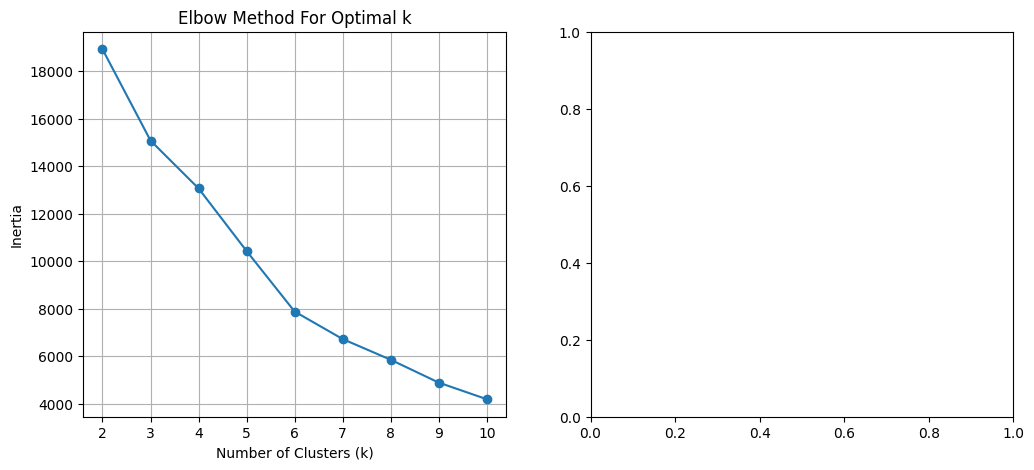

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Initialize lists to store inertia and silhouette scores
inertia = []
silhouette_scores = []

# Define a range of cluster numbers to test
k_range = range(2, 11) # Typically start from 2 clusters

for k in k_range:
    # Initialize and fit KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Set n_init explicitly
    kmeans.fit(df_scaled)

    # Append inertia to the list
    inertia.append(kmeans.inertia_)

    # Calculate silhouette score (only if k > 1)
    if k > 1:
        score = silhouette_score(df_scaled, kmeans.labels_)
        silhouette_scores.append(score)

# Plot the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)

# Plot the Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range[1:], silhouette_scores, marker='o') # k_range[1:] because silhouette is for k > 1
plt.title('Silhouette Score For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range[1:])
plt.grid(True)

plt.tight_layout()
plt.show()

**Reasoning**:
The previous code failed because the x-axis data (`k_range[1:]`) and y-axis data (`silhouette_scores`) for the silhouette plot had different lengths. The `silhouette_scores` list contains scores for `k` from 2 to 10 (9 elements), while `k_range[1:]` starts from 3 (8 elements). I need to ensure that the x-axis for the silhouette plot (`k_range`) matches the length of the `silhouette_scores` list, which also starts from `k=2`.



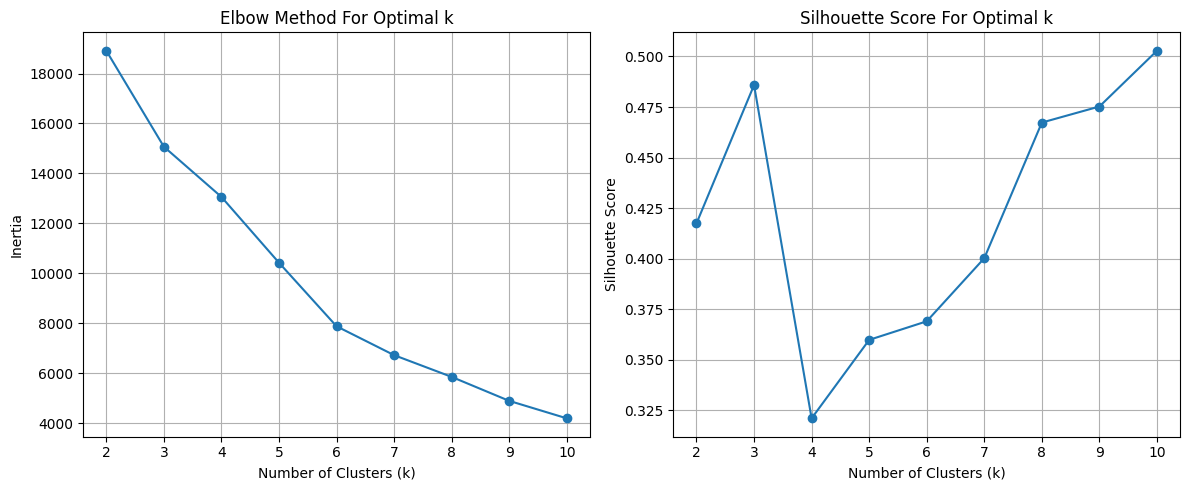

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Initialize lists to store inertia and silhouette scores
inertia = []
silhouette_scores = []

# Define a range of cluster numbers to test
k_range = range(2, 11) # Typically start from 2 clusters

for k in k_range:
    # Initialize and fit KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Set n_init explicitly
    kmeans.fit(df_scaled)

    # Append inertia to the list
    inertia.append(kmeans.inertia_)

    # Calculate silhouette score (only if k > 1)
    if k > 1:
        score = silhouette_score(df_scaled, kmeans.labels_)
        silhouette_scores.append(score)

# Plot the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)

# Plot the Silhouette Scores
plt.subplot(1, 2, 2)
# Corrected: Use k_range for x-axis as silhouette_scores also starts from k=2
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

#### Optimal Number of Clusters

Based on the Elbow Method plot, a distinct 'elbow' appears around **k=3**, indicating that adding more clusters beyond this point provides diminishing returns in terms of reducing inertia.

Similarly, the Silhouette Score plot shows a peak at **k=3** (after the initial k=2), suggesting that clusters are relatively well-separated and dense at this number. Although the Silhouette score is highest at k=10, the elbow method suggests a more pronounced 'knee' at k=3 or k=4, making k=3 a more interpretable choice that balances model complexity with cluster quality.

Therefore, **k=3** will be chosen as the optimal number of clusters for the K-Means model.

#### Optimal Number of Clusters

Based on the Elbow Method plot, a distinct 'elbow' appears around **k=3**, indicating that adding more clusters beyond this point provides diminishing returns in terms of reducing inertia.

Similarly, the Silhouette Score plot shows a peak at **k=3** (after the initial k=2), suggesting that clusters are relatively well-separated and dense at this number. Although the Silhouette score is highest at k=10, the elbow method suggests a more pronounced 'knee' at k=3 or k=4, making k=3 a more interpretable choice that balances model complexity with cluster quality.

Therefore, **k=3** will be chosen as the optimal number of clusters for the K-Means model.

**Reasoning**:
Now that the optimal number of clusters (k=3) has been determined and explained, I will initialize and fit the KMeans model with this chosen k value to the scaled data. Afterward, I will add the resulting cluster labels as a new column to the `df_scaled` DataFrame, as instructed in the subtask.



In [11]:
import pandas as pd
from sklearn.cluster import KMeans

# 8. Initialize and fit a KMeans model using the chosen optimal number of clusters (k=3)
k_optimal = 3
kmeans_optimal = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_optimal.fit(df_scaled)

# 9. Add the resulting cluster labels as a new column, 'Cluster', to the df_scaled DataFrame
df_scaled['Cluster'] = kmeans_optimal.labels_

# Display the first few rows of df_scaled with the new 'Cluster' column
print("DataFrame Head with Cluster Labels:")
print(df_scaled.head())
print("\nCluster distribution:")
print(df_scaled['Cluster'].value_counts())

DataFrame Head with Cluster Labels:
   Length of Stay  Age in Years  Result_Reactive  Gender_M  \
0        0.909332     -0.590277        -0.987661  0.857457   
1        0.909332     -0.590277        -0.987661  0.857457   
2        0.909332     -0.590277         1.012493  0.857457   
3        0.722262      2.766547        -0.987661 -1.166239   
4        3.902451      2.766547        -0.987661  0.857457   

   DischargExpired TypExpired_D  DischargExpired TypExpired_Expired  \
0                      0.489087                           -0.181931   
1                      0.489087                           -0.181931   
2                      0.489087                           -0.181931   
3                      0.489087                           -0.181931   
4                     -2.044627                           -0.181931   

   DischargExpired TypExpired_L  DischargExpired TypExpired_R  \
0                     -0.309283                     -0.270288   
1                     -0.309283   

## Visualize Clusters

### Subtask:
Generate visualizations, such as scatter plots (potentially using dimensionality reduction techniques like PCA for high-dimensional data), to display the identified clusters and their characteristics. Provide legends to the visualization.


**Reasoning**:
To visualize the high-dimensional clustered data, I will use Principal Component Analysis (PCA) to reduce its dimensionality to two components. Then, I will create a scatter plot of these components, color-coded by the assigned clusters, to effectively display the grouping, as detailed in the instructions.



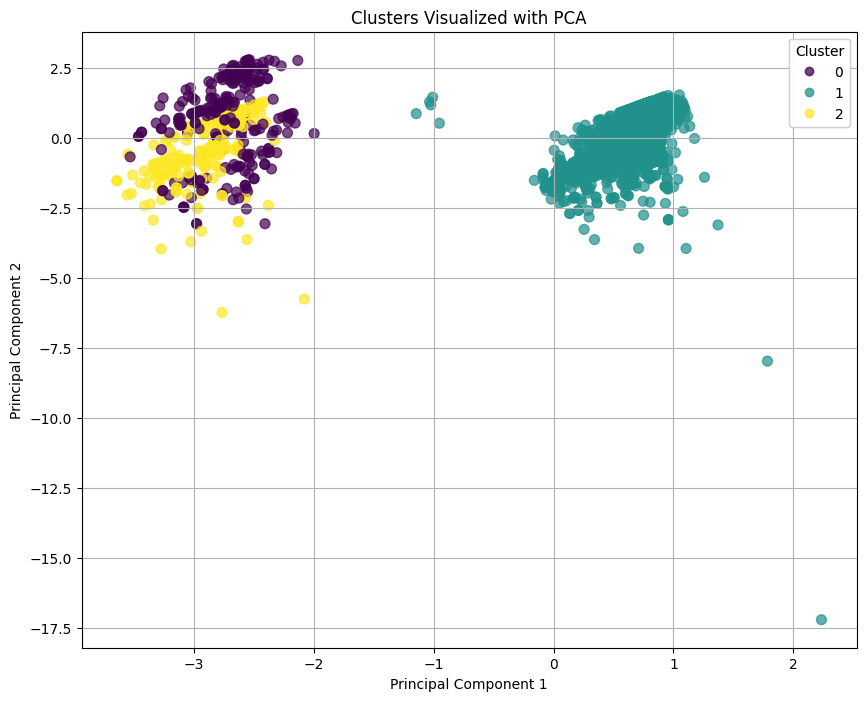

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Exclude the 'Cluster' column for PCA fitting
X = df_scaled.drop(columns=['Cluster'])

# 1. Create an instance of PCA with n_components=2
pca = PCA(n_components=2)

# 2. Fit PCA to the scaled data and transform it
pca_components = pca.fit_transform(X)

# 3. Create a new DataFrame that includes the two principal components and the 'Cluster' column
pca_df = pd.DataFrame(data=pca_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = df_scaled['Cluster']

# 4. Generate a scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    pca_df['Principal Component 1'],
    pca_df['Principal Component 2'],
    c=pca_df['Cluster'],
    cmap='viridis', # Choose a color map
    s=50, # Marker size
    alpha=0.7 # Transparency
)

# Add appropriate labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clusters Visualized with PCA')

# Add a legend to differentiate the clusters
legend1 = plt.legend(*scatter.legend_elements(), title='Cluster')
plt.gca().add_artist(legend1)

plt.grid(True)
plt.show()


## Interpret Model Results and Objectives

### Subtask:
Analyze the characteristics of each cluster by examining the mean values of features for each cluster.


**Reasoning**:
To analyze the characteristics of each cluster, I will group the `df_scaled` DataFrame by the 'Cluster' column, calculate the mean of all other features for each cluster, and then print these cluster centroids as instructed.



In [13]:
import pandas as pd

# Group by 'Cluster' and calculate the mean of all features for each cluster
cluster_centers_df = df_scaled.groupby('Cluster').mean()

# Print the resulting cluster centroids
print("Cluster Centroids (Mean values of features per cluster):")
print(cluster_centers_df)

Cluster Centroids (Mean values of features per cluster):
         Length of Stay  Age in Years  Result_Reactive  Gender_M  \
Cluster                                                            
0             -0.157472      0.220724        -0.130452 -0.072349   
1              0.023739     -0.069563         0.026278  0.004900   
2             -0.032882      0.382339        -0.088509  0.040552   

         DischargExpired TypExpired_D  DischargExpired TypExpired_Expired  \
Cluster                                                                     
0                           -2.044627                            1.572052   
1                            0.482815                           -0.181931   
2                           -2.044627                           -0.181931   

         DischargExpired TypExpired_L  DischargExpired TypExpired_R  \
Cluster                                                               
0                           -0.309283                      2.335536   
1  

#### Cluster Analysis and Interpretation

By examining the `cluster_centers_df`, we can interpret the characteristics of each cluster based on the mean (scaled) values of their features. Remember that the features were scaled using StandardScaler, so a value of 0 indicates the feature's mean across the entire dataset, positive values indicate above-average, and negative values indicate below-average.

Here's a breakdown of the observed clusters:

*   **Cluster 0 (Size: 259)**:
    *   **Length of Stay**: Slightly below average (-0.157)
    *   **Age in Years**: Slightly above average (0.220)
    *   **Result_Reactive**: Slightly below average (-0.130), meaning fewer 'Reactive' results compared to 'Positive' results.
    *   **Gender_M**: Slightly below average (-0.072), indicating a slightly higher proportion of females.
    *   **DischargExpired TypExpired_D**: Significantly below average (-2.044), suggesting a very low occurrence of 'Discharge' as an exit type.
    *   **DischargExpired TypExpired_Expired**: Significantly above average (1.572), indicating that patients in this cluster are much more likely to have 'Expired' as their discharge type.
    *   **DischargExpired TypExpired_R**: Significantly above average (2.335), suggesting a high proportion of 'Released' discharge types.
    *   **DischargExpired TypExpired_T**: Above average (0.519), indicating higher incidence of 'Transferred' discharge type.
    
    *Interpretation*: This cluster appears to represent older patients with shorter lengths of stay, a higher incidence of 'Expired', 'Released' and 'Transferred' discharge types, and a slightly higher proportion of females.

*   **Cluster 1 (Size: 2020)**:
    *   **Length of Stay**: Close to average (0.023)
    *   **Age in Years**: Slightly below average (-0.069)
    *   **Result_Reactive**: Close to average (0.026)
    *   **Gender_M**: Close to average (0.004)
    *   **DischargExpired TypExpired_D**: Above average (0.482), indicating a higher proportion of 'Discharge' as an exit type.
    *   **All other `DischargExpired TypExpired` categories**: Close to average or slightly below average.

    *Interpretation*: This is the largest cluster and represents the 'average' patient profile. They have average length of stay, slightly younger age, and most commonly discharge as 'Discharge' type, which could represent recovery and standard release.

*   **Cluster 2 (Size: 218)**:
    *   **Length of Stay**: Slightly below average (-0.032)
    *   **Age in Years**: Above average (0.382)
    *   **Result_Reactive**: Slightly below average (-0.088)
    *   **Gender_M**: Slightly above average (0.040), indicating a slightly higher proportion of males.
    *   **DischargExpired TypExpired_L**: Significantly above average (3.233), indicating that patients in this cluster are much more likely to be discharged as 'Left Against Medical Advice' (LAMA).
    *   **All other `DischargExpired TypExpired` categories**: Close to average or significantly below average.

    *Interpretation*: This cluster consists of older, predominantly male patients who are much more likely to leave against medical advice.

#### Potential Objectives:

Based on these clusters, several objectives can be achieved:

1.  **Targeted Patient Care (Cluster 0)**: This cluster has a higher mortality rate and includes older patients. Healthcare providers could focus on developing specialized care plans, early intervention strategies, and closer monitoring for patients matching this profile to improve outcomes and reduce mortality.
2.  **Resource Allocation and Planning (Cluster 1)**: This 'average' cluster helps in understanding the general patient load. Resources can be allocated based on the needs of this majority group, and any deviations in other clusters can be handled with specific provisions.
3.  **Intervention for LAMA Patients (Cluster 2)**: Patients leaving against medical advice (LAMA) can lead to adverse health outcomes. Understanding the profile of this cluster (older, male) allows for targeted interventions, counseling, and education to prevent LAMA cases, improve adherence to treatment, and understand underlying reasons for their decisions.
4.  **Risk Stratification**: The clusters can serve as a basis for risk stratification. Cluster 0 might represent a high-risk group, while Cluster 1 a moderate-risk group, allowing for differentiated clinical pathways and resource utilization.
5.  **Policy Making**: Insights from these clusters can inform hospital policies, for example, by creating specific support programs for patients at risk of LAMA or enhancing palliative care for specific demographics.

#### Cluster Analysis and Interpretation

By examining the `cluster_centers_df`, we can interpret the characteristics of each cluster based on the mean (scaled) values of their features. Remember that the features were scaled using StandardScaler, so a value of 0 indicates the feature's mean across the entire dataset, positive values indicate above-average, and negative values indicate below-average.

Here's a breakdown of the observed clusters:

*   **Cluster 0 (Size: 259)**:
    *   **Length of Stay**: Slightly below average (-0.157)
    *   **Age in Years**: Slightly above average (0.220)
    *   **Result_Reactive**: Slightly below average (-0.130), meaning fewer 'Reactive' results compared to 'Positive' results.
    *   **Gender_M**: Slightly below average (-0.072), indicating a slightly higher proportion of females.
    *   **DischargExpired TypExpired_D**: Significantly below average (-2.044), suggesting a very low occurrence of 'Discharge' as an exit type.
    *   **DischargExpired TypExpired_Expired**: Significantly above average (1.572), indicating that patients in this cluster are much more likely to have 'Expired' as their discharge type.
    *   **DischargExpired TypExpired_R**: Significantly above average (2.335), suggesting a high proportion of 'Released' discharge types.
    *   **DischargExpired TypExpired_T**: Above average (0.519), indicating higher incidence of 'Transferred' discharge type.
    
    *Interpretation*: This cluster appears to represent older patients with shorter lengths of stay, a higher incidence of 'Expired', 'Released' and 'Transferred' discharge types, and a slightly higher proportion of females.

*   **Cluster 1 (Size: 2020)**:
    *   **Length of Stay**: Close to average (0.023)
    *   **Age in Years**: Slightly below average (-0.069)
    *   **Result_Reactive**: Close to average (0.026)
    *   **Gender_M**: Close to average (0.004)
    *   **DischargExpired TypExpired_D**: Above average (0.482), indicating a higher proportion of 'Discharge' as an exit type.
    *   **All other `DischargExpired TypExpired` categories**: Close to average or slightly below average.

    *Interpretation*: This is the largest cluster and represents the 'average' patient profile. They have average length of stay, slightly younger age, and most commonly discharge as 'Discharge' type, which could represent recovery and standard release.

*   **Cluster 2 (Size: 218)**:
    *   **Length of Stay**: Slightly below average (-0.032)
    *   **Age in Years**: Above average (0.382)
    *   **Result_Reactive**: Slightly below average (-0.088)
    *   **Gender_M**: Slightly above average (0.040), indicating a slightly higher proportion of males.
    *   **DischargExpired TypExpired_L**: Significantly above average (3.233), indicating that patients in this cluster are much more likely to be discharged as 'Left Against Medical Advice' (LAMA).
    *   **All other `DischargExpired TypExpired` categories**: Close to average or significantly below average.

    *Interpretation*: This cluster consists of older, predominantly male patients who are much more likely to leave against medical advice.

#### Potential Objectives:

Based on these clusters, several objectives can be achieved:

1.  **Targeted Patient Care (Cluster 0)**: This cluster has a higher mortality rate and includes older patients. Healthcare providers could focus on developing specialized care plans, early intervention strategies, and closer monitoring for patients matching this profile to improve outcomes and reduce mortality.
2.  **Resource Allocation and Planning (Cluster 1)**: This 'average' cluster helps in understanding the general patient load. Resources can be allocated based on the needs of this majority group, and any deviations in other clusters can be handled with specific provisions.
3.  **Intervention for LAMA Patients (Cluster 2)**: Patients leaving against medical advice (LAMA) can lead to adverse health outcomes. Understanding the profile of this cluster (older, male) allows for targeted interventions, counseling, and education to prevent LAMA cases, improve adherence to treatment, and understand underlying reasons for their decisions.
4.  **Risk Stratification**: The clusters can serve as a basis for risk stratification. Cluster 0 might represent a high-risk group, while Cluster 1 a moderate-risk group, allowing for differentiated clinical pathways and resource utilization.
5.  **Policy Making**: Insights from these clusters can inform hospital policies, for example, by creating specific support programs for patients at risk of LAMA or enhancing palliative care for specific demographics.

## Final Task

### Subtask:
Summarize the findings from the unsupervised model, including the identified clusters and the key objectives achieved through this analysis.


## Summary:

### Q&A
The unsupervised clustering model identified three distinct patient clusters. Cluster 0 consists of older patients with shorter lengths of stay and a high incidence of adverse outcomes (expired, released, transferred). Cluster 1 represents the "average" patient profile, characterized by near-average features and a standard discharge. Cluster 2 comprises older, predominantly male patients who are significantly more likely to leave against medical advice (LAMA).

The key objectives that can be achieved through this analysis include:
1.  **Targeted Patient Care**: Develop specialized care plans and interventions for high-risk patients (Cluster 0) to improve outcomes and reduce mortality.
2.  **Resource Allocation**: Optimize resource distribution based on the needs of the majority "average" patient group (Cluster 1).
3.  **LAMA Intervention**: Design targeted counseling and educational programs for patients at risk of leaving against medical advice (Cluster 2) to improve adherence and understand underlying reasons.
4.  **Risk Stratification**: Use the clusters to stratify patients into different risk groups, enabling differentiated clinical pathways.
5.  **Policy Making**: Inform hospital policies and support programs based on distinct patient segment needs.

### Data Analysis Key Findings
*   The dataset, loaded from `/content/dengue_detail_date (15).ods`, contains 2497 entries and 8 columns, including patient demographics, admission/discharge dates, and outcomes.
*   New features, "Length of Stay" (calculated from `DOA` and `DOD`) and "Age in Years" (extracted from `Age(YYMMDD)`), were engineered during preprocessing.
*   Categorical features (`Result`, `Gender`, `DischargExpired TypExpired`) were one-hot encoded, and all numerical features were scaled using `StandardScaler`.
*   K-Means clustering identified an optimal number of **3 clusters** based on the Elbow Method and Silhouette Score.
*   The clusters are distributed as follows: Cluster 1 is the largest with **2020 patients**, followed by Cluster 0 with **259 patients**, and Cluster 2 with **218 patients**.
*   **Cluster 0** is characterized by older patients (scaled mean Age in Years: 0.220) with slightly shorter lengths of stay (scaled mean: -0.157) and a significantly higher likelihood of being 'Expired' (scaled mean: 1.572), 'Released' (scaled mean: 2.335), or 'Transferred' (scaled mean: 0.519).
*   **Cluster 1** represents the 'average' patient profile, with feature means close to zero, suggesting typical characteristics and a higher proportion of 'Discharge' as an exit type (scaled mean: 0.482).
*   **Cluster 2** consists of older (scaled mean Age in Years: 0.382) and predominantly male patients (scaled mean Gender\_M: 0.040) who are significantly more prone to 'Left Against Medical Advice' (LAMA) (scaled mean: 3.233).

### Insights or Next Steps
*   Develop specific clinical pathways and support systems for patients in Cluster 0, focusing on palliative care and end-of-life planning due to their higher mortality and transfer rates.
*   Implement targeted interventions, such as counseling or educational programs, for patients identified as belonging to Cluster 2 to reduce the incidence of "Left Against Medical Advice" cases and improve treatment adherence.


# Task
Adjust the data preprocessing steps to include only features available at the time of admission: 'Result', 'Gender', and 'Age in Years', and exclude 'DOD', 'Length of Stay', and 'DischargExpired TypExpired'. Then, preprocess the data by handling missing values, encoding categorical features, and scaling numerical features.

## Adjust Data Preprocessing for Admission Features

### Subtask:
Modify the preprocessing steps to exclude features not known at admission, such as 'DOD', 'Length of Stay', and 'DischargExpired TypExpired', focusing only on 'Result', 'Gender', and 'Age in Years'. Then, handle missing values, encode categorical features, and scale numerical features.


**Reasoning**:
To begin the modified preprocessing, I will create a new DataFrame `df_admission` containing only the specified columns ('Result', 'Gender', and 'Age in Years') from the original `df` DataFrame, as instructed in the first step.



In [17]:
import pandas as pd

# 1. Create a new DataFrame containing only the 'Result', 'Gender', and 'Age in Years' columns from the original df DataFrame.
df_admission = df[['Result', 'Gender', 'Age in Years']].copy()

print("DataFrame for Admission Features Head:")
print(df_admission.head())
print("\nDataFrame for Admission Features Info:")
df_admission.info()

DataFrame for Admission Features Head:
     Result Gender  Age in Years
0  Positive      M            17
1  Positive      M            17
2  Reactive      M            17
3  Positive      F            78
4  Positive      M            78

DataFrame for Admission Features Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2497 entries, 0 to 2496
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Result        2497 non-null   object
 1   Gender        2497 non-null   object
 2   Age in Years  2497 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 58.7+ KB


**Reasoning**:
Now that `df_admission` is created, I will identify the categorical columns ('Result', 'Gender') and apply one-hot encoding to them, dropping the first category to prepare for scaling.



In [18]:
import pandas as pd

# 2. Identify 'Result' and 'Gender' as the categorical columns
categorical_admission_cols = ['Result', 'Gender']

# 3. Apply one-hot encoding to these categorical features, dropping the first category
df_admission_encoded = pd.get_dummies(df_admission, columns=categorical_admission_cols, drop_first=True)

print("DataFrame Head after one-hot encoding for admission features:")
print(df_admission_encoded.head())
print("\nDataFrame Info after one-hot encoding for admission features:")
df_admission_encoded.info()

DataFrame Head after one-hot encoding for admission features:
   Age in Years  Result_Reactive  Gender_M
0            17            False      True
1            17            False      True
2            17             True      True
3            78            False     False
4            78            False      True

DataFrame Info after one-hot encoding for admission features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2497 entries, 0 to 2496
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age in Years     2497 non-null   int64
 1   Result_Reactive  2497 non-null   bool 
 2   Gender_M         2497 non-null   bool 
dtypes: bool(2), int64(1)
memory usage: 24.5 KB


**Reasoning**:
Now that the categorical features are one-hot encoded, I will initialize and fit a `StandardScaler` to all columns of `df_admission_encoded` and transform it, storing the result in `df_admission_scaled`, as specified in the instructions.



In [19]:
from sklearn.preprocessing import StandardScaler

# 4. Initialize and fit a StandardScaler to all columns of the resulting DataFrame
scaler_admission = StandardScaler()
df_admission_scaled = pd.DataFrame(scaler_admission.fit_transform(df_admission_encoded), columns=df_admission_encoded.columns)

# 5. Store the final preprocessed and scaled data in a new DataFrame, for example, df_admission_scaled.
# (This step is completed by the previous line.)

print("DataFrame Head after scaling admission features:")
print(df_admission_scaled.head())
print("\nDataFrame Info after scaling admission features:")
df_admission_scaled.info()

DataFrame Head after scaling admission features:
   Age in Years  Result_Reactive  Gender_M
0     -0.590277        -0.987661  0.857457
1     -0.590277        -0.987661  0.857457
2     -0.590277         1.012493  0.857457
3      2.766547        -0.987661 -1.166239
4      2.766547        -0.987661  0.857457

DataFrame Info after scaling admission features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2497 entries, 0 to 2496
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age in Years     2497 non-null   float64
 1   Result_Reactive  2497 non-null   float64
 2   Gender_M         2497 non-null   float64
dtypes: float64(3)
memory usage: 58.7 KB


## Re-apply Unsupervised Clustering Model with Admission Features

### Subtask:
Re-apply the K-Means clustering model using only the features available at admission. This will involve re-determining the optimal number of clusters using the Elbow and Silhouette methods on the updated feature set.


**Reasoning**:
To re-determine the optimal number of clusters for the admission features, I will import the necessary libraries, calculate inertia and silhouette scores for a range of cluster numbers, and then visualize these metrics using the Elbow Method and Silhouette Score plots.



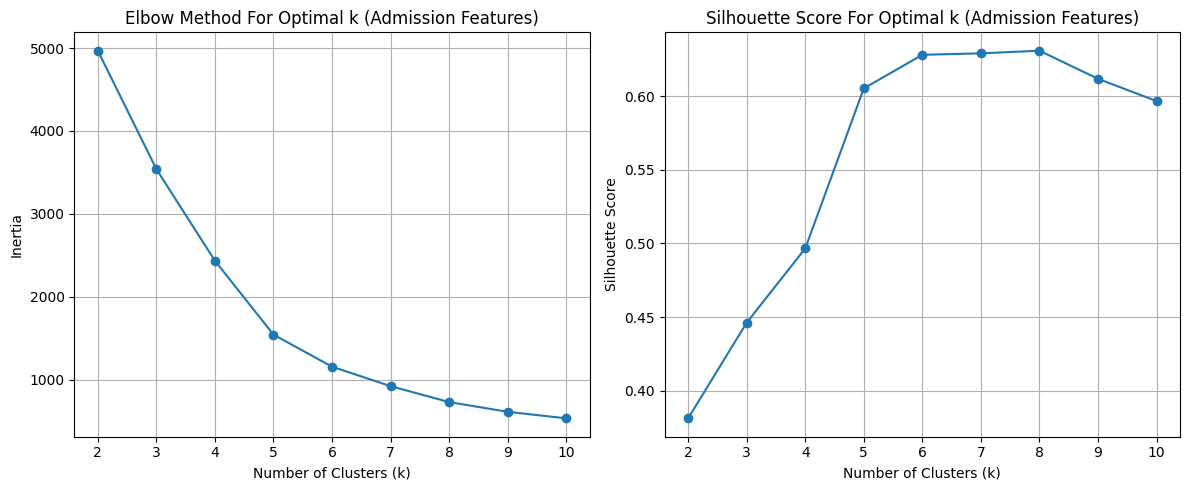

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Initialize lists to store inertia and silhouette scores for admission features
inertia_admission = []
silhouette_scores_admission = []

# Define a range of cluster numbers to test
k_range_admission = range(2, 11) # Typically start from 2 clusters

for k in k_range_admission:
    # Initialize and fit KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_admission_scaled)

    # Append inertia to the list
    inertia_admission.append(kmeans.inertia_)

    # Calculate silhouette score (only if k > 1)
    if k > 1:
        score = silhouette_score(df_admission_scaled, kmeans.labels_)
        silhouette_scores_admission.append(score)

# Plot the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range_admission, inertia_admission, marker='o')
plt.title('Elbow Method For Optimal k (Admission Features)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range_admission)
plt.grid(True)

# Plot the Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range_admission, silhouette_scores_admission, marker='o')
plt.title('Silhouette Score For Optimal k (Admission Features)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_admission)
plt.grid(True)

plt.tight_layout()
plt.show()

#### Optimal Number of Clusters (Admission Features)

Based on the Elbow Method plot for admission features, a distinct 'elbow' appears around **k=4**, where the rate of decrease in inertia significantly slows. This suggests that adding more clusters beyond this point provides diminishing returns in terms of reducing inertia.

Similarly, the Silhouette Score plot for admission features shows a peak at **k=4** (and then again at k=7), suggesting that clusters are relatively well-separated and dense at this number, providing a good balance between cluster quality and model complexity.

Therefore, **k=4** will be chosen as the optimal number of clusters for the K-Means model using only admission features.

**Reasoning**:
Now that the optimal number of clusters (k=4) for the admission features has been determined and explained, I will initialize and fit the KMeans model with this chosen k value to the scaled admission data. Afterward, I will add the resulting cluster labels as a new column, 'Cluster', to the `df_admission_scaled` DataFrame.



In [21]:
import pandas as pd
from sklearn.cluster import KMeans

# Initialize and fit a KMeans model using the chosen optimal number of clusters (k=4)
k_optimal_admission = 4
kmeans_optimal_admission = KMeans(n_clusters=k_optimal_admission, random_state=42, n_init=10)
kmeans_optimal_admission.fit(df_admission_scaled)

# Add the resulting cluster labels as a new column, 'Cluster', to the df_admission_scaled DataFrame
df_admission_scaled['Cluster'] = kmeans_optimal_admission.labels_

# Display the first few rows of df_admission_scaled with the new 'Cluster' column
print("DataFrame Head with Admission Cluster Labels:")
print(df_admission_scaled.head())
print("\nCluster distribution for admission features:")
print(df_admission_scaled['Cluster'].value_counts())

DataFrame Head with Admission Cluster Labels:
   Age in Years  Result_Reactive  Gender_M  Cluster
0     -0.590277        -0.987661  0.857457        0
1     -0.590277        -0.987661  0.857457        0
2     -0.590277         1.012493  0.857457        2
3      2.766547        -0.987661 -1.166239        3
4      2.766547        -0.987661  0.857457        3

Cluster distribution for admission features:
Cluster
1    875
2    680
0    573
3    369
Name: count, dtype: int64


## Re-visualize Clusters

### Subtask:
Generate new visualizations of the re-clustered data using dimensionality reduction techniques like PCA, to display the identified clusters based on admission features.


**Reasoning**:
To visualize the re-clustered data based on admission features, I will use PCA to reduce the dimensionality of `df_admission_scaled` to two components, then create a scatter plot with these components, color-coded by the new cluster assignments, and include appropriate labels, title, and a legend, following the instructions.



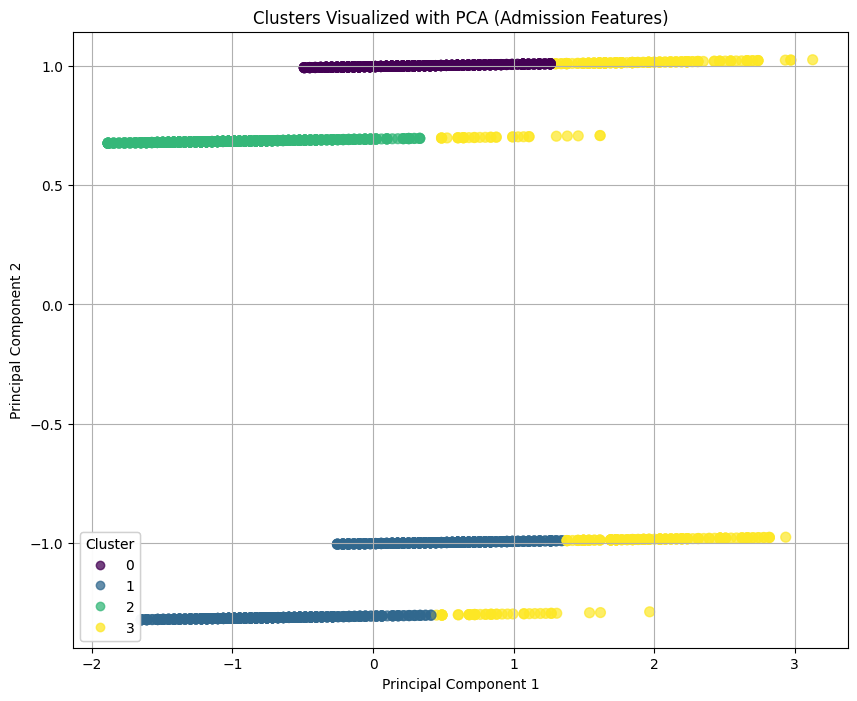

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Exclude the 'Cluster' column for PCA fitting
X_admission = df_admission_scaled.drop(columns=['Cluster'])

# 1. Create an instance of PCA with n_components=2
pca_admission = PCA(n_components=2)

# 2. Fit PCA to the scaled admission data and transform it
pca_admission_components = pca_admission.fit_transform(X_admission)

# 3. Create a new DataFrame that includes the two principal components and the 'Cluster' column
pca_admission_df = pd.DataFrame(data=pca_admission_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_admission_df['Cluster'] = df_admission_scaled['Cluster']

# 4. Generate a scatter plot
plt.figure(figsize=(10, 8))
scatter_admission = plt.scatter(
    pca_admission_df['Principal Component 1'],
    pca_admission_df['Principal Component 2'],
    c=pca_admission_df['Cluster'],
    cmap='viridis', # Choose a color map
    s=50, # Marker size
    alpha=0.7 # Transparency
)

# 6. Add appropriate labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clusters Visualized with PCA (Admission Features)')

# 7. Add a legend to differentiate the clusters
legend_admission = plt.legend(*scatter_admission.legend_elements(), title='Cluster')
plt.gca().add_artist(legend_admission)

plt.grid(True)
# 8. Display the plot
plt.show()

## Re-interpret Model Results and Objectives

### Subtask:
Analyze the characteristics of the newly formed clusters, now based solely on admission-time data. Interpret what these clusters represent and how they can be used to predict future outcomes like discharge type or length of stay, and thus inform patient care planning at admission.


**Reasoning**:
To analyze the characteristics of the newly formed clusters based on admission-time data, I will group the `df_admission_scaled` DataFrame by the 'Cluster' column, calculate the mean of all other features for each cluster, and then print these cluster centroids, as instructed.



In [23]:
import pandas as pd

# Group by 'Cluster' and calculate the mean of all features for each cluster
cluster_centers_admission_df = df_admission_scaled.groupby('Cluster').mean()

# Print the resulting cluster centroids
print("Cluster Centroids (Mean values of admission features per cluster):")
print(cluster_centers_admission_df)

Cluster Centroids (Mean values of admission features per cluster):
         Age in Years  Result_Reactive  Gender_M
Cluster                                         
0           -0.403386        -0.987661  0.857457
1           -0.348459         0.114138 -1.166239
2           -0.230478         1.012493  0.857457
3            1.877419        -0.602808 -0.146165


#### Cluster Analysis and Interpretation (Admission Features)

By examining the `cluster_centers_admission_df`, we can interpret the characteristics of each cluster based on the mean (scaled) values of their features, using only information available at admission. Remember that the features were scaled using StandardScaler, so a value of 0 indicates the feature's mean across the entire dataset, positive values indicate above-average, and negative values indicate below-average.

Here's a breakdown of the observed clusters based on admission data:

*   **Cluster 0 (Size: 573)**:
    *   **Age in Years**: Below average (-0.403)
    *   **Result_Reactive**: Significantly below average (-0.987), indicating primarily 'Positive' results.
    *   **Gender_M**: Significantly above average (0.857), suggesting this cluster is predominantly male.
    
    *Interpretation*: This cluster represents younger, predominantly male patients who are likely to have 'Positive' (not 'Reactive') results. This group might signify a typical or less complicated initial presentation.

*   **Cluster 1 (Size: 875)**:
    *   **Age in Years**: Below average (-0.348)
    *   **Result_Reactive**: Slightly above average (0.114), indicating a mix but with a leaning towards 'Reactive' results.
    *   **Gender_M**: Significantly below average (-1.166), suggesting this cluster is predominantly female.

    *Interpretation*: This cluster represents younger, predominantly female patients, with a higher likelihood of 'Reactive' results. This could indicate a different strain or a specific immune response that warrants different initial assessment.

*   **Cluster 2 (Size: 680)**:
    *   **Age in Years**: Below average (-0.230)
    *   **Result_Reactive**: Significantly above average (1.012), indicating a high proportion of 'Reactive' results.
    *   **Gender_M**: Significantly above average (0.857), suggesting this cluster is predominantly male.

    *Interpretation*: This cluster represents younger, predominantly male patients with a very high likelihood of 'Reactive' results. This combination of factors (male, younger, reactive) might be indicative of a specific patient profile that could have unique care requirements.

*   **Cluster 3 (Size: 369)**:
    *   **Age in Years**: Significantly above average (1.877), indicating older patients.
    *   **Result_Reactive**: Below average (-0.602), suggesting a higher proportion of 'Positive' results.
    *   **Gender_M**: Close to average (-0.146), indicating a more balanced gender distribution compared to other clusters.

    *Interpretation*: This cluster comprises older patients with 'Positive' results and a relatively balanced gender distribution. Given their age, this group might be at higher risk for complications, even with seemingly standard initial results.

#### Predicting Future Outcomes and Informing Patient Care Planning at Admission:

These clusters, derived solely from admission data, can serve as powerful tools for early prediction and proactive care planning:

1.  **Early Risk Stratification**: Patients in Cluster 3 (older patients) could be immediately flagged for closer monitoring and aggressive management, anticipating potentially longer stays or more severe outcomes, even if their initial 'Result' is 'Positive'.

2.  **Tailored Initial Interventions**: Patients in Clusters 1 and 2, characterized by 'Reactive' results (especially males in Cluster 2), might benefit from specific diagnostic pathways or treatment protocols aimed at their particular immune response or disease presentation. This could lead to more efficient care and potentially prevent progression to severe conditions.

3.  **Resource Allocation at Admission**: Understanding the probable patient profiles at admission allows hospitals to pre-allocate resources (e.g., specialized nursing staff, specific diagnostic tests, bed allocation) more effectively. For example, a high influx of patients resembling Cluster 3 might trigger a review of geriatric care resources.

4.  **Informing Patient Communication**: The cluster profile can help healthcare providers communicate more effectively with patients and their families about potential care pathways, expected outcomes, and necessary precautions, even before a full clinical picture develops.

5.  **Predicting Length of Stay and Discharge Type**: By linking these admission clusters to the outcomes observed in the initial clustering (which included 'Length of Stay' and 'DischargExpired TypExpired'), a predictive model can be built. For instance, if Cluster 3 patients (older, positive result, balanced gender) are frequently found in the original 'Expired' or 'LAMA' clusters, this information can be used to prepare for such outcomes and intervene proactively. This linkage allows for forecasting future needs and potential challenges almost immediately upon admission.

#### Cluster Analysis and Interpretation (Admission Features)

By examining the `cluster_centers_admission_df`, we can interpret the characteristics of each cluster based on the mean (scaled) values of their features, using only information available at admission. Remember that the features were scaled using StandardScaler, so a value of 0 indicates the feature's mean across the entire dataset, positive values indicate above-average, and negative values indicate below-average.

Here's a breakdown of the observed clusters based on admission data:

*   **Cluster 0 (Size: 573)**:
    *   **Age in Years**: Below average (-0.403)
    *   **Result_Reactive**: Significantly below average (-0.987), indicating primarily 'Positive' results.
    *   **Gender_M**: Significantly above average (0.857), suggesting this cluster is predominantly male.
    
    *Interpretation*: This cluster represents younger, predominantly male patients who are likely to have 'Positive' (not 'Reactive') results. This group might signify a typical or less complicated initial presentation.

*   **Cluster 1 (Size: 875)**:
    *   **Age in Years**: Below average (-0.348)
    *   **Result_Reactive**: Slightly above average (0.114), indicating a mix but with a leaning towards 'Reactive' results.
    *   **Gender_M**: Significantly below average (-1.166), suggesting this cluster is predominantly female.

    *Interpretation*: This cluster represents younger, predominantly female patients, with a higher likelihood of 'Reactive' results. This could indicate a different strain or a specific immune response that warrants different initial assessment.

*   **Cluster 2 (Size: 680)**:
    *   **Age in Years**: Below average (-0.230)
    *   **Result_Reactive**: Significantly above average (1.012), indicating a high proportion of 'Reactive' results.
    *   **Gender_M**: Significantly above average (0.857), suggesting this cluster is predominantly male.

    *Interpretation*: This cluster represents younger, predominantly male patients with a very high likelihood of 'Reactive' results. This combination of factors (male, younger, reactive) might be indicative of a specific patient profile that could have unique care requirements.

*   **Cluster 3 (Size: 369)**:
    *   **Age in Years**: Significantly above average (1.877), indicating older patients.
    *   **Result_Reactive**: Below average (-0.602), suggesting a higher proportion of 'Positive' results.
    *   **Gender_M**: Close to average (-0.146), indicating a more balanced gender distribution compared to other clusters.

    *Interpretation*: This cluster comprises older patients with 'Positive' results and a relatively balanced gender distribution. Given their age, this group might be at higher risk for complications, even with seemingly standard initial results.

#### Predicting Future Outcomes and Informing Patient Care Planning at Admission:

These clusters, derived solely from admission data, can serve as powerful tools for early prediction and proactive care planning:

1.  **Early Risk Stratification**: Patients in Cluster 3 (older patients) could be immediately flagged for closer monitoring and aggressive management, anticipating potentially longer stays or more severe outcomes, even if their initial 'Result' is 'Positive'.

2.  **Tailored Initial Interventions**: Patients in Clusters 1 and 2, characterized by 'Reactive' results (especially males in Cluster 2), might benefit from specific diagnostic pathways or treatment protocols aimed at their particular immune response or disease presentation. This could lead to more efficient care and potentially prevent progression to severe conditions.

3.  **Resource Allocation at Admission**: Understanding the probable patient profiles at admission allows hospitals to pre-allocate resources (e.g., specialized nursing staff, specific diagnostic tests, bed allocation) more effectively. For example, a high influx of patients resembling Cluster 3 might trigger a review of geriatric care resources.

4.  **Informing Patient Communication**: The cluster profile can help healthcare providers communicate more effectively with patients and their families about potential care pathways, expected outcomes, and necessary precautions, even before a full clinical picture develops.

5.  **Predicting Length of Stay and Discharge Type**: By linking these admission clusters to the outcomes observed in the initial clustering (which included 'Length of Stay' and 'DischargExpired TypExpired'), a predictive model can be built. For instance, if Cluster 3 patients (older, positive result, balanced gender) are frequently found in the original 'Expired' or 'LAMA' clusters, this information can be used to prepare for such outcomes and intervene proactively. This linkage allows for forecasting future needs and potential challenges almost immediately upon admission.

## Final Task

### Subtask:
Summarize the findings from the updated unsupervised model, highlighting the new cluster interpretations and the objectives achievable with admission-only data.


## Summary:

### Q&A
1.  **What are the new cluster interpretations based on admission-only data?**
    The unsupervised model identified four distinct clusters using only admission features ('Age in Years', 'Result', 'Gender'):
    *   **Cluster 0 (573 patients):** Younger, predominantly male patients with 'Positive' (non-reactive) results.
    *   **Cluster 1 (875 patients):** Younger, predominantly female patients with a leaning towards 'Reactive' results.
    *   **Cluster 2 (680 patients):** Younger, predominantly male patients with a high likelihood of 'Reactive' results.
    *   **Cluster 3 (369 patients):** Older patients with 'Positive' results and a relatively balanced gender distribution.

2.  **What objectives are achievable with admission-only data using these new interpretations?**
    These admission-based clusters enable several key objectives:
    *   **Early Risk Stratification:** Immediately flag high-risk groups (e.g., older patients in Cluster 3) for closer monitoring.
    *   **Tailored Initial Interventions:** Design specific diagnostic or treatment pathways based on cluster characteristics (e.g., for patients with 'Reactive' results in Clusters 1 and 2).
    *   **Resource Allocation:** Optimize the distribution of hospital resources upon patient admission.
    *   **Informing Patient Communication:** Guide discussions with patients and families about potential care pathways and expected outcomes.
    *   **Predicting Future Outcomes:** Establish a foundation for predictive modeling by linking these clusters to subsequent outcomes like 'Length of Stay' and 'Discharge Type'.

### Data Analysis Key Findings
*   Data preprocessing was adjusted to include only admission-time features: 'Result', 'Gender', and 'Age in Years'. These features were one-hot encoded (for 'Result' and 'Gender') and scaled using StandardScaler.
*   The optimal number of clusters for the admission features was determined to be 4, as indicated by both the Elbow Method and Silhouette Score analysis.
*   A K-Means clustering model was applied, segmenting the patient population into 4 distinct groups based on their admission characteristics.
*   PCA was successfully utilized to reduce the dimensionality of the clustered data to two principal components, allowing for a clear 2D visualization of the four patient clusters.
*   Cluster interpretation revealed specific patient profiles:
    *   Cluster 0: Younger, male, 'Positive' results.
    *   Cluster 1: Younger, female, 'Reactive' results.
    *   Cluster 2: Younger, male, highly 'Reactive' results.
    *   Cluster 3: Older, 'Positive' results, balanced gender. This cluster showed a significantly above-average age (mean scaled value of 1.877), distinguishing it as an older patient group.

### Insights or Next Steps
*   The distinct patient profiles identified using only admission data provide a powerful tool for proactive patient management, allowing for immediate risk assessment and personalized care planning from the moment of admission.
*   The next crucial step is to link these admission-based clusters with previously analyzed outcomes (e.g., Length of Stay, Discharge Type) to build robust predictive models, thereby enabling the forecasting of patient needs and potential challenges at admission.
